# DIABETES DIAGNOSIS   

Diabetes is a chronic disease that affects how the body turns food into energy. While there's no cure, it can be managed with medications if diagnosed early. Many factors are considered a potential risk factor (BMI, age) or an indicator (HbA1c level, blood glucose level) of diabetes. We want to be able to predict the probability that a patient will be diagnosed with Diabetes so it can be managed.

In [53]:
#importing the necessary packages
import numpy as np 
import pandas as pd 
from janitor import * 

In [54]:
#Loading the data
diabetes = pd.read_csv('diabetes_prediction_dataset.csv')

#displaying the first 5 rows
display(diabetes.head(5))

#displaying the last five rows
display(diabetes.tail(5))

#Checking for the information of the dataset
print(diabetes.info())

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0
99999,Female,57.0,0,0,current,22.43,6.6,90,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB
None


#### Data Cleaning and Interrogation

In [55]:
#Number of rows and columns before cleaning
rows_columns = diabetes.shape
print(f'The number of rows are {rows_columns[0]} and number of columns are {rows_columns[1]} before cleaning')

#missing values
no_of_missing = diabetes.isna().sum()
print(no_of_missing)

#duplicates
no_of_duplicates = diabetes.duplicated().sum()

print(f'There are {no_of_duplicates} duplicate records')

#Dropping duplicate records
diabetes_clean = diabetes.drop_duplicates()
print(f'There are {diabetes_clean.duplicated().sum()} duplicate records after cleaning')

#Number of rows and columns after cleaning
rows_columns2 = diabetes_clean.shape
print(f'The number of rows are {rows_columns2[0]} and number of columns are {rows_columns2[1]} after cleaning')

The number of rows are 100000 and number of columns are 9 before cleaning
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64
There are 3854 duplicate records
There are 0 duplicate records after cleaning
The number of rows are 96146 and number of columns are 9 after cleaning


In [56]:
#Statistical description
display(diabetes_clean.describe())

#Checking for the skewness
display(diabetes_clean.select_dtypes(include=[int, float]).skew())

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000
mean,41.794326,0.077601,0.040803,27.321461,5.532609,138.218231,0.088220
std,22.462948,0.267544,0.197833,6.767716,1.073232,40.909771,0.283616
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.000000,0.000000,23.400000,4.800000,100.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,59.000000,0.000000,0.000000,29.860000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


age                   -0.062445
hypertension           3.157676
heart_disease          4.642359
bmi                    1.023751
HbA1c_level           -0.054463
blood_glucose_level    0.836489
diabetes               2.903845
dtype: float64

The heart disease and hypertension columns are the highest skewed (right-skewed). 

#### Results from Data Interrogation & Data Cleaning
- The Diabetes data had 100000 records and 9 columns before cleaning
- There were 3854 duplicate records and no missing values.
- After cleaning, the dataset had 96146 records and 9 columns.
- Three columns (hypertension, heart_disease and diabetes) were right skewed.
- The dataset had different data types especially float and integer data types.

##### Data Exploration  

1) What is the distribution of Diabetes diagnosis among patients? Percentage of diabetic and non-diabetic patients.

In [57]:
#importing the package for visualisation
from plotnine import *

#Checking for the counts of diabetic & non-diabetic patients
diabetes_diag = diabetes_clean['diabetes'].value_counts().reset_index(name = 'count')

#Checking for the percentage distribution of Diabetic & Non-diabetic patients
diabetes_diag['perc'] = round((diabetes_diag['count'] / diabetes_diag['count'].sum()), 3)
print(diabetes_diag)

#Mapping the diabetes column to convert from numbers to words. 0 - Not Diabetic; 1 - Diabetic
diabetes_diag['diabetes'] = diabetes_diag['diabetes'].map({0:'Not diabetic', 1:'Diabetic'})

   diabetes  count   perc
0         0  87664  0.912
1         1   8482  0.088


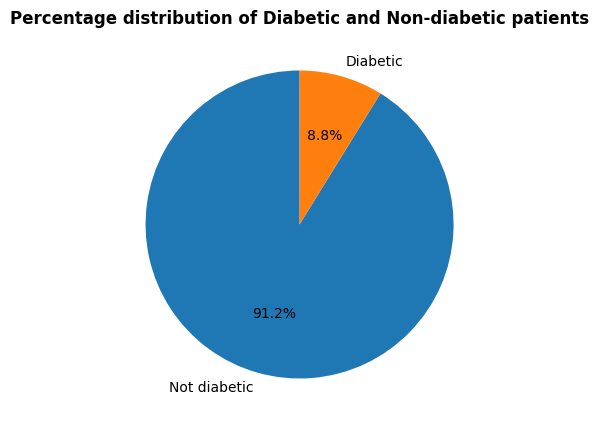

In [58]:
#Visualising in a pie chart...
import matplotlib.pyplot as plt 

plt.figure(figsize=(5, 5))
plt.pie(diabetes_diag['perc'], labels= diabetes_diag['diabetes'],
        autopct='%1.1f%%', 
        startangle=90)
plt.title('Percentage distribution of Diabetic and Non-diabetic patients', fontweight = 'bold')
plt.show()

**Plot Interpretation:** The pie chart show that there is a alot more Non-diabetic patients than diabetic ones in this dataset.

2) What is the gender distribution of patients?

,gender,diabetes,count
0,Female,Not Diabetic,51714
1,Female,Diabetic,4447
2,Male,Not Diabetic,35932
3,Male,Diabetic,4035
4,Other,Not Diabetic,18


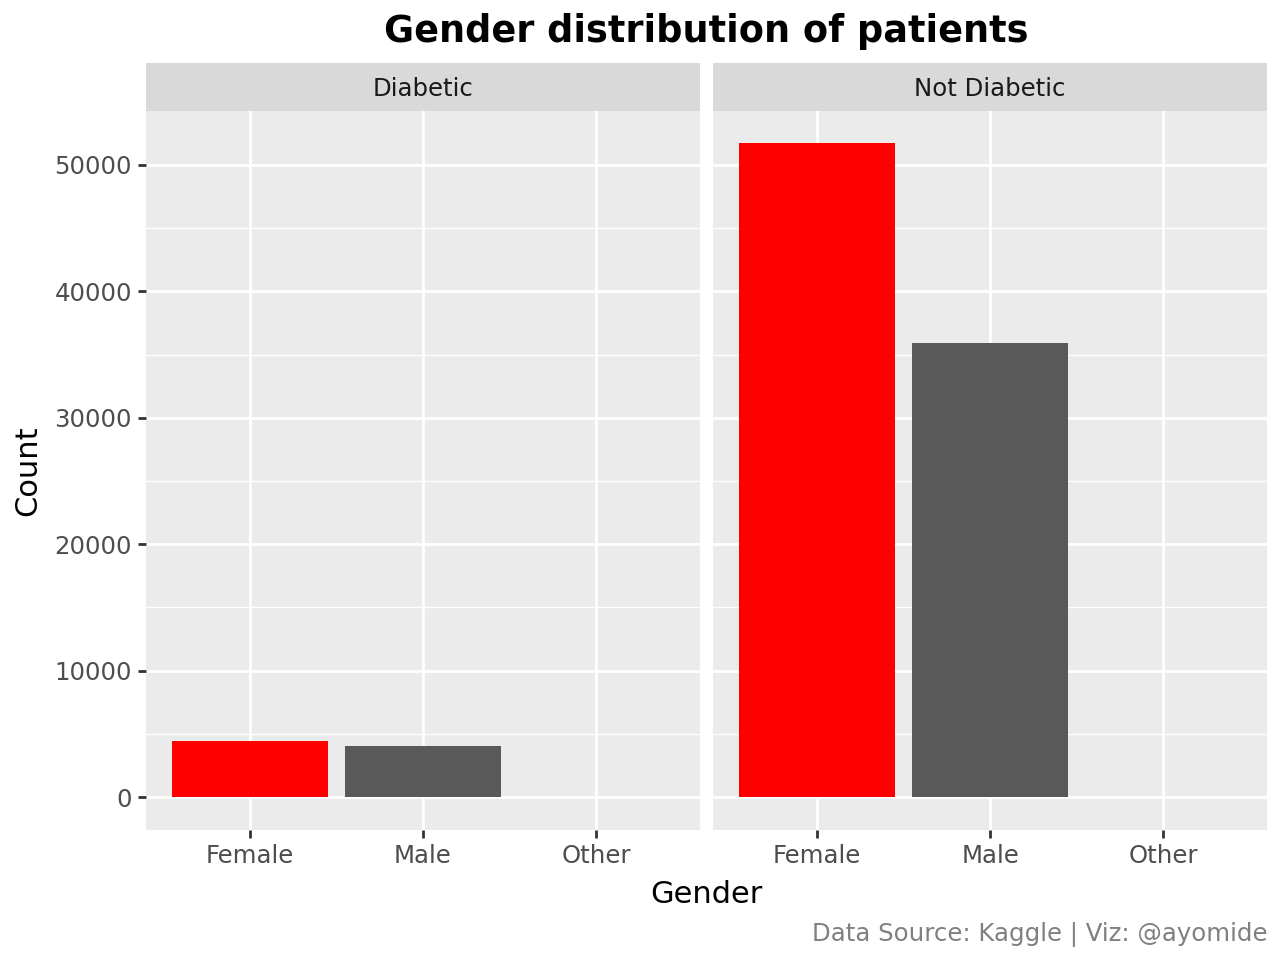

In [59]:
#Grouping the dataset to check for the gender counts of diabetic patient & non-diabetic patients
gender_patient = diabetes_clean[['gender','diabetes']].groupby(['gender','diabetes']).size().reset_index(name='count')

#Mapping the diabetes column to convert from numbers to words. 0 - Not Diabetic; 1 - Diabetic
gender_patient['diabetes'] = gender_patient['diabetes'].map({0: 'Not Diabetic', 1: 'Diabetic'})

#Filtering for the females only
fem = gender_patient[gender_patient['gender']== 'Female']

display(gender_patient)

#Visualising....
(ggplot(gender_patient, aes('gender', 'count')) + geom_col() + geom_col(fem, aes('gender', 'count'), fill = 'red') + facet_wrap('diabetes')
+ labs(x = 'Gender', 
       y = 'Count',
       title= 'Gender distribution of patients',
       caption= 'Data Source: Kaggle | Viz: @ayomide')
+ theme(plot_caption=element_text(color='grey'), plot_title=element_text(fontweight = 'bold')))

**Plot Interpretation:** The plot shows that there are more females records in the dataset and they have the most number of diabetic patients.

3) Is age correlated with diabetes diagnosis?

               age  diabetes
age       1.000000  0.264927
diabetes  0.264927  1.000000


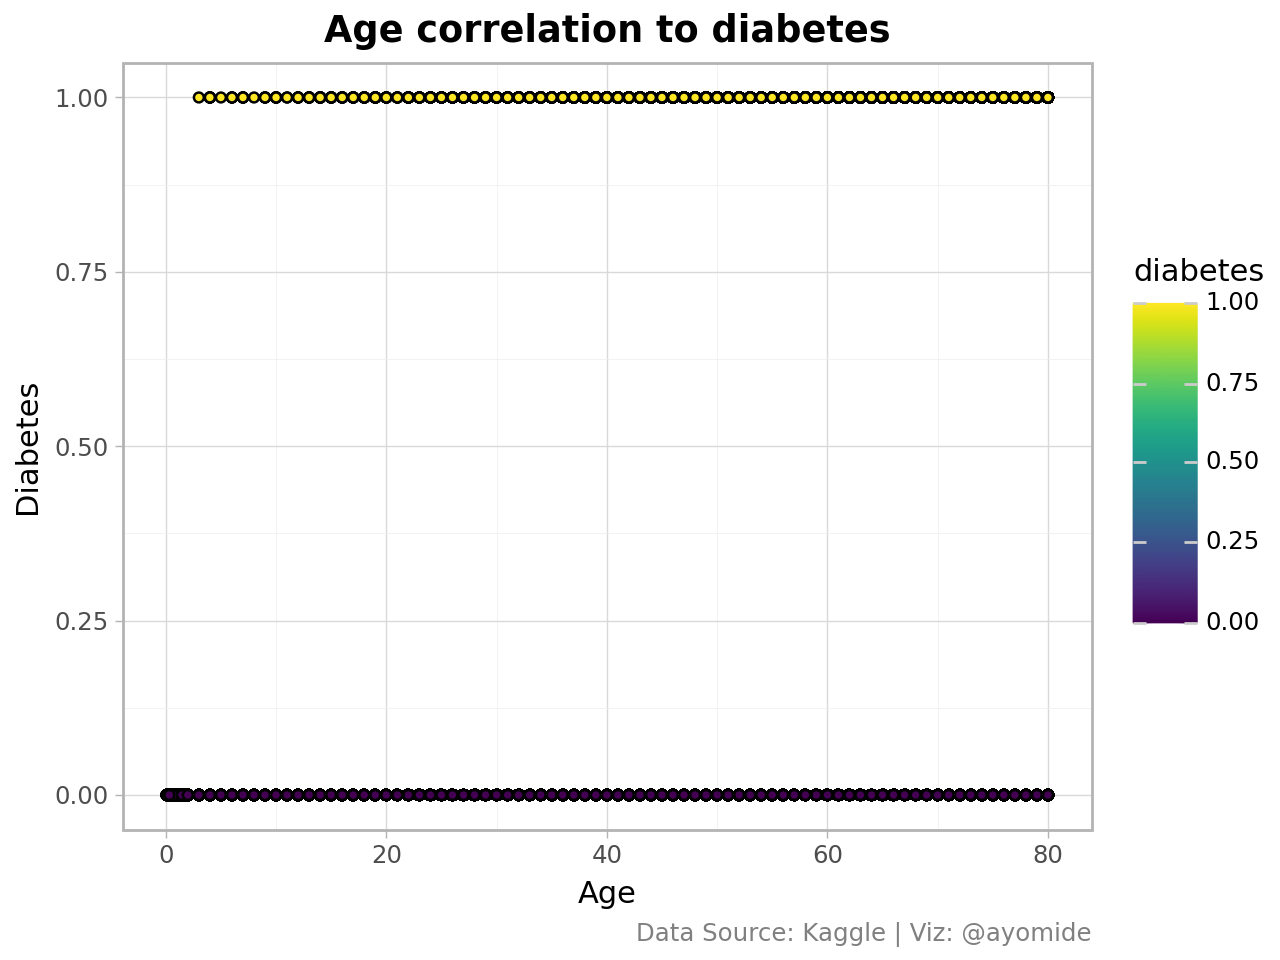

In [60]:
#Selecting the two columns of Interest
age_diabetes = diabetes_clean[['age', 'diabetes']]

#Checking for the correlation between both columns (age & diabetes)
print(age_diabetes.corr())

#Visualising in a scatter plot
(ggplot(age_diabetes, aes('age', 'diabetes', fill = 'diabetes')) + geom_point()
 + labs(x = 'Age', 
       y = 'Diabetes',
       title= 'Age correlation to diabetes',
       caption= 'Data Source: Kaggle | Viz: @ayomide')
+ theme_light()
+ theme(plot_caption=element_text(color='grey'), plot_title=element_text(fontweight = 'bold')))

**Plot Interpretation:** Age has a correlation of about 0.27 which is low. The plot shows a poor relationship between age and diabetes. This means that any age except 0 can be diagnosed with diabetes. Diabetes diagnosis doesn't depend on age.

4) Which age group has the most diabetes? 

In [61]:
#Creating an age group column in the age_diabetes df created previously
age_diabetes['age_group'] = pd.cut(age_diabetes['age'], bins = [0, 12, 18, 44, 64, float("inf")], labels=['0-12', '13-18', '19-44', '45-64', '65+'])

age_diabetes.head(5)

C:\Users\HomePC\AppData\Local\Temp\ipykernel_14156\3029824934.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


,age,diabetes,age_group
0,80.0,0,65+
1,54.0,0,45-64
2,28.0,0,19-44
3,36.0,0,19-44
4,76.0,0,65+


In [62]:
#Grouping the dataset to check for the age_group counts of diabetic patient & non-diabetic patients
age_dia = age_diabetes.groupby(['age_group', 'diabetes']).size().reset_index(name = 'count')

#Creating a total column for the total number of patients in each age group (diabetic + non-diabetic)
age_dia['total'] = age_dia.groupby('age_group')['count'].transform('sum')

#Creating a perc column for the percentage of diabetic or non-diabetic patients in each group / total number of patients
age_dia['perc'] = age_dia['count'] / age_dia['total']

#Filtering for the diabetic ones
age_diaa = age_dia[age_dia['diabetes'] == 1]
age_diaa

C:\Users\HomePC\AppData\Local\Temp\ipykernel_14156\3295128793.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
C:\Users\HomePC\AppData\Local\Temp\ipykernel_14156\3295128793.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,age_group,diabetes,count,total,perc
1,0-12,1,36,11989,0.003003
3,13-18,1,56,5831,0.009604
5,19-44,1,1014,32562,0.031141
7,45-64,1,3591,28108,0.127757
9,65+,1,3785,17656,0.214375


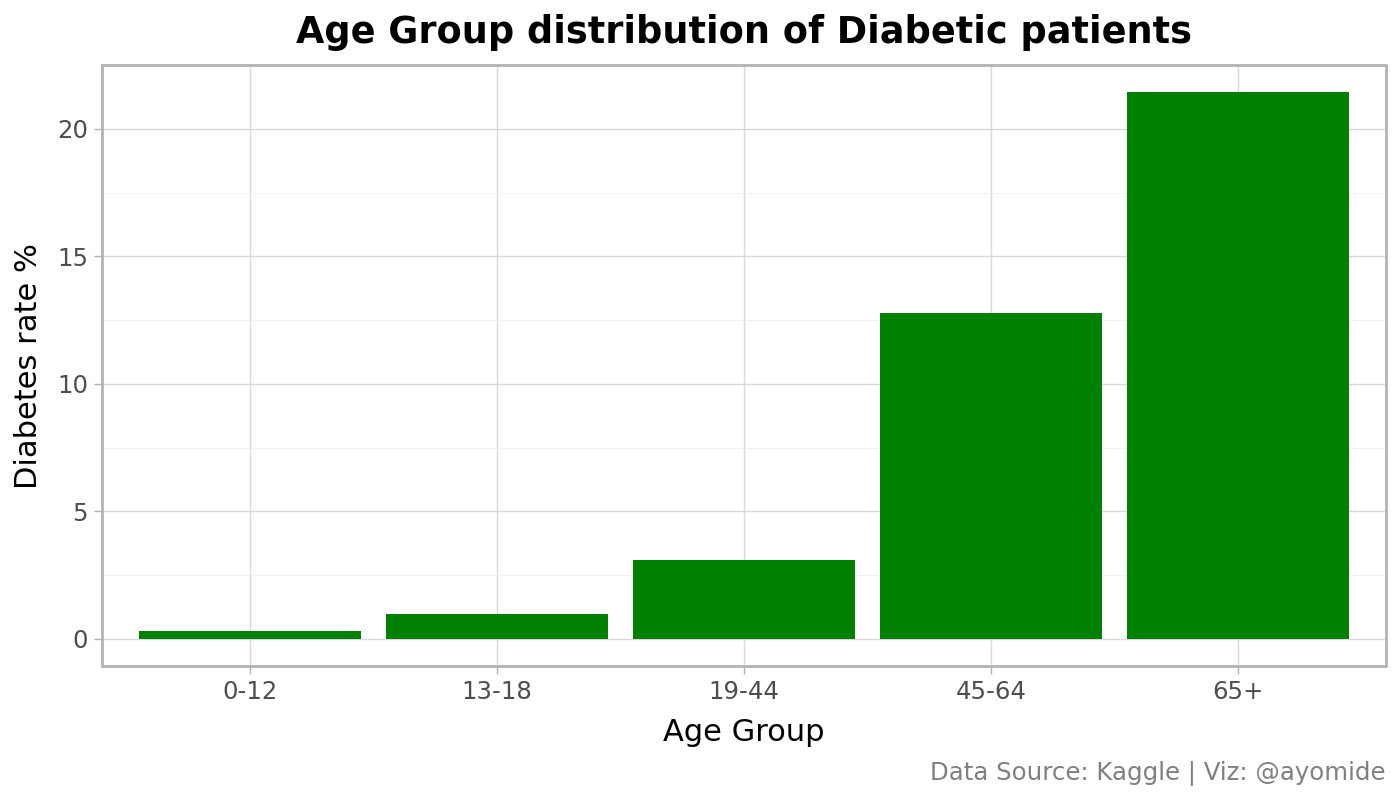

In [63]:
#Visualising using a bar plot...
(ggplot(age_diaa, aes('age_group', 'perc')) 
 + geom_col(fill = '#008000')
 + scale_y_continuous(labels=lambda l: [f'{x * 100:.0f}' for x in l])
 + labs(x = 'Age Group', 
       y = 'Diabetes rate %',
       title= 'Age Group distribution of Diabetic patients',
       caption= 'Data Source: Kaggle | Viz: @ayomide')
+ theme_light()
+ theme(plot_caption=element_text(color='grey'), plot_title=element_text(fontweight = 'bold'), figure_size=(7, 4)))

**Plot Interpretation:** The Elderly (age 65+) have the highest cases of Diabetes (about 21%) while the infants (age 0-12) have the least case. This could be an indicator that diabetes is hereditary i.e. genetics and family history play a role.

5) Is hypertension associated with a diabetes diagnosis? 

In [64]:
#Selecting the two columns of Interest
hypertension1 = diabetes_clean[['hypertension', 'diabetes']]

#Grouping the dataset to check for the counts of diabetic patient & non-diabetic patients with hypertension
hyp_dia = hypertension1.groupby(['hypertension', 'diabetes']).size().reset_index(name = 'count')

#Creating a total column for the total number of patients (hypertensive + not hypertensive)
hyp_dia['total'] = hyp_dia.groupby('hypertension')['count'].transform('sum')

#Creating a perc column for the percentage of diabetic or non-diabetic patients with or without hypertension / total number of patients
hyp_dia['perc'] = hyp_dia['count'] / hyp_dia['total']

#Mapping the diabetes & hypertension columns to convert from numbers to words. 0 - Not Diabetic; 1 - Diabetic, 0 - Not hypetensive; 1- Hypertensive
hyp_dia['diabetes'] = hyp_dia['diabetes'].map({0: 'Not Diabetic', 1: 'Diabetic'})
hyp_dia['hypertension'] = hyp_dia['hypertension'].map({0: 'Not Hypertensive', 1: 'Hypertensive'})

hyp_dia


,hypertension,diabetes,count,total,perc
0,Not Hypertensive,Not Diabetic,82289,88685,0.927880
1,Not Hypertensive,Diabetic,6396,88685,0.072120
2,Hypertensive,Not Diabetic,5375,7461,0.720413
3,Hypertensive,Diabetic,2086,7461,0.279587


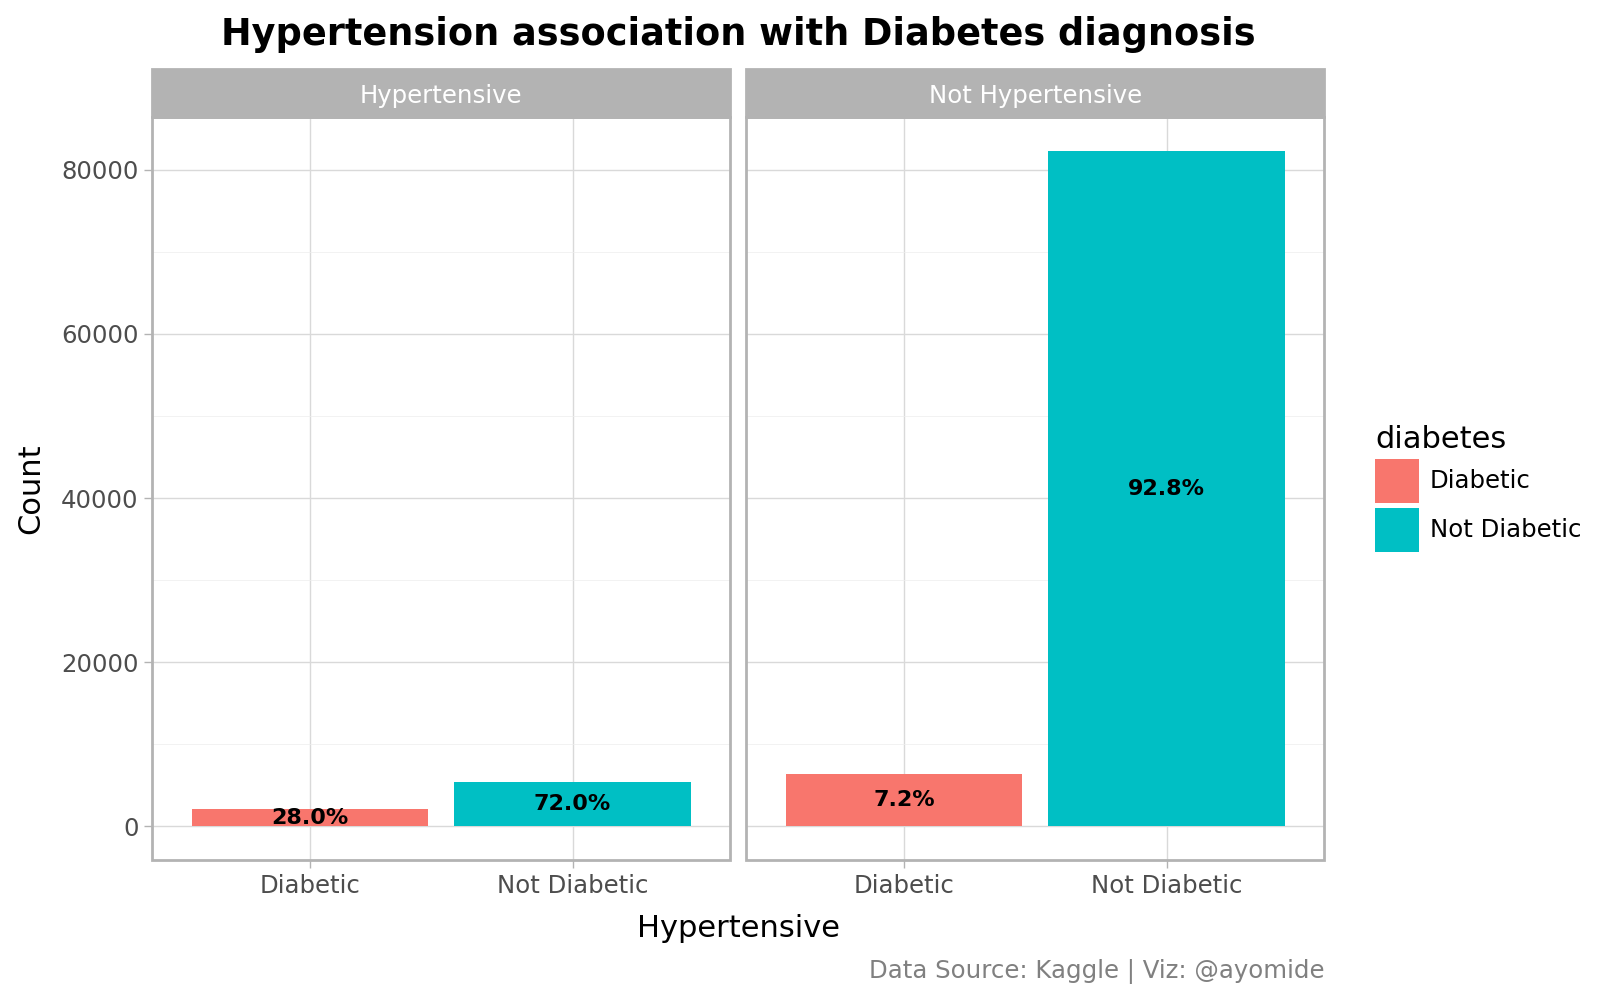

In [65]:
#Visualising...
(ggplot(hyp_dia, aes('diabetes', 'count', fill = 'diabetes')) 
 + geom_col()
 + facet_wrap('hypertension')
+ geom_text(aes(label = 'perc'), format_string = '{:.1%}', fontweight = 'bold', position = position_stack(vjust = 0.5), size = 8)
 + labs(x = 'Hypertensive', 
       y = 'Count',
       title= 'Hypertension association with Diabetes diagnosis',
       caption= 'Data Source: Kaggle | Viz: @ayomide')
+ theme_light()
+ theme(plot_caption=element_text(color='grey'), plot_title=element_text(fontweight = 'bold'), figure_size=(8, 5)))


Chi-square test of Independence

H₀ (null hypothesis)
- Hypertension and Diabetes are independent.
- (There is no relationship between hypertension and diabetes.)

H₁ (alternative hypothesis)
- Hypertension and Diabetes are associated.
- (The diagnosis of diabetes across patient differs by hypertensive diagnosis)

Significance level  
0.05 or 5%

In [66]:
import pingouin as pg 
hypertension2 = hypertension1 
hypertension2['diabetes'] = hypertension2['diabetes'].map({0: 'Not Diabetic', 1: 'Diabetic'})
hypertension2['hypertension'] = hypertension2['hypertension'].map({0: 'Not Hypertensive', 1: 'Hypertensive'})

expected, observed, stats = pg.chi2_independence(data = hypertension1, x = "hypertension", y = "diabetes")

display(stats)


C:\Users\HomePC\AppData\Local\Temp\ipykernel_14156\2764085933.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
C:\Users\HomePC\AppData\Local\Temp\ipykernel_14156\2764085933.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.000000,3680.032936,1.0,0.0,0.195641,1.0
1,cressie-read,0.666667,3229.530904,1.0,0.0,0.183275,1.0
2,log-likelihood,0.000000,2581.392129,1.0,0.0,0.163856,1.0
3,freeman-tukey,-0.500000,2249.795234,1.0,0.0,0.152970,1.0
4,mod-log-likelihood,-1.000000,2007.739452,1.0,0.0,0.144507,1.0
5,neyman,-2.000000,1699.027586,1.0,0.0,0.132934,1.0


**Interpretation:** The plot shows no association between hypertension and diabetes. Most of the Hypertensive patients are non-diabetic and most of the diabetic patients are not hypertensive.   
A chi-square test of independence was conducted. The results showed a non-statistically significant association between hypertension and diabetes diagnosis.  
The Pearson's chi-square test of independence revealed chi2(1, N = 96146) = 3680.032936, p = 0, with a moderate strength of association (cramer = 0.20), thereby accepting the null hypothesis that says hypertension is not associated with diabetes.

6) Is heart disease associated with diabetes diagnosis?

In [67]:
#Selecting the two columns of Interest
heart_diab = diabetes_clean[['heart_disease', 'diabetes']]

#Grouping the dataset to check for the counts of diabetic patient & non-diabetic patients with heart diseases
heart_dia = heart_diab.groupby(['heart_disease', 'diabetes']).size().reset_index(name = 'count')

#Creating a total column for the total number of patients (with heart diseases + no heart disease)
heart_dia['total'] = heart_dia.groupby('heart_disease')['count'].transform('sum')

#Creating a perc column for the percentage of diabetic or non-diabetic patients with or without heart diseases / total number of patients
heart_dia['perc'] = heart_dia['count'] / heart_dia['total']

#Mapping the diabetes & hypertension columns to convert from numbers to words. 0 - Not Diabetic; 1 - Diabetic, 0 - No Heart disease; 1- Heart disease
heart_dia['diabetes'] = heart_dia['diabetes'].map({0: 'Not Diabetic', 1: 'Diabetic'})
heart_dia['heart_disease'] = heart_dia['heart_disease'].map({0: 'No Heart Disease', 1: 'Heart Disease'})


heart_dia

,heart_disease,diabetes,count,total,perc
0,No Heart Disease,Not Diabetic,85008,92223,0.921766
1,No Heart Disease,Diabetic,7215,92223,0.078234
2,Heart Disease,Not Diabetic,2656,3923,0.677033
3,Heart Disease,Diabetic,1267,3923,0.322967


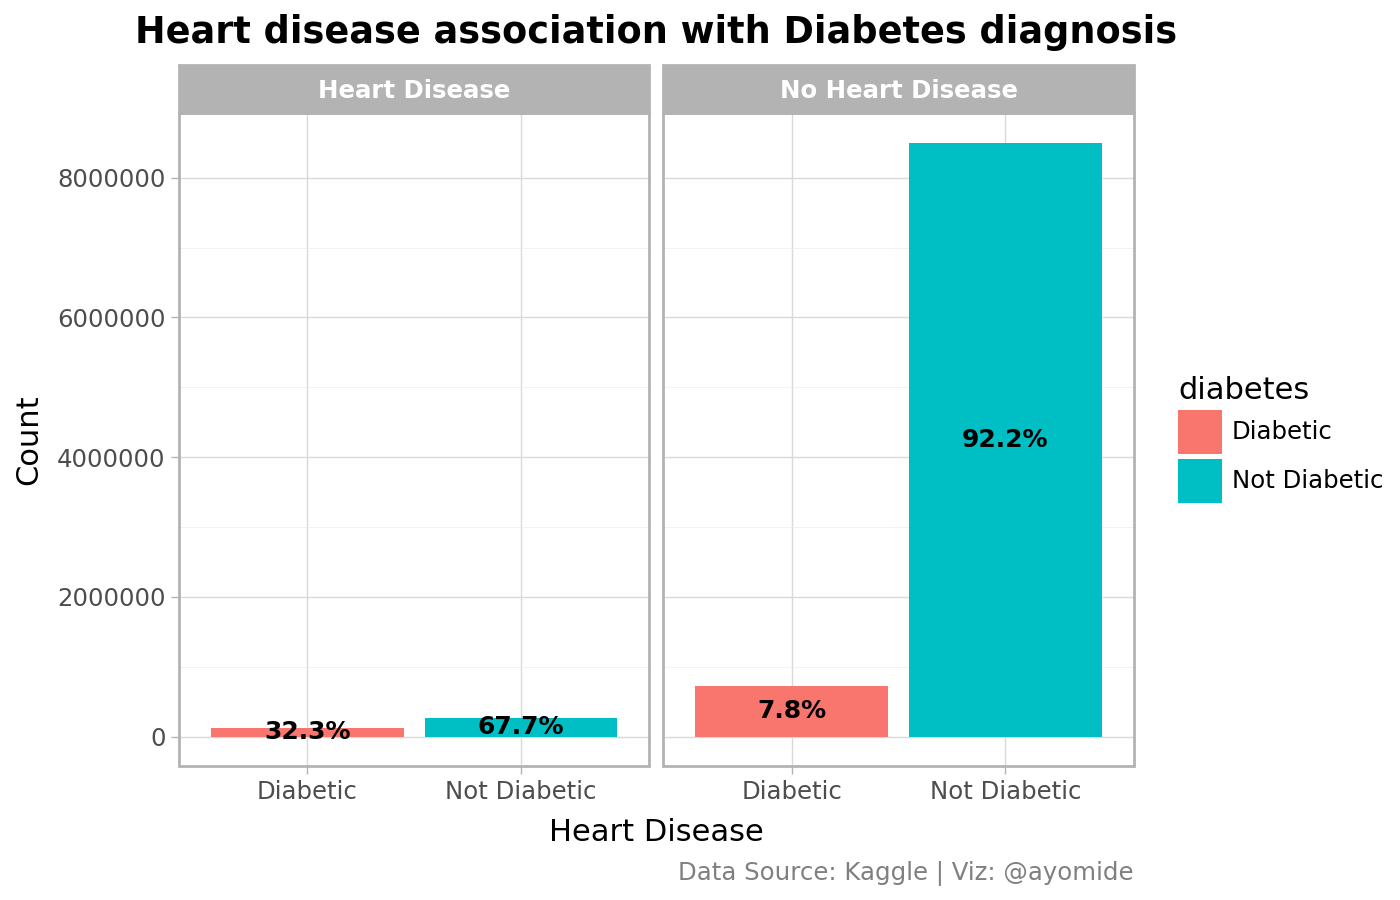

In [68]:
#Visualising...
(ggplot(heart_dia, aes('diabetes', 'count', fill = 'diabetes')) 
 + geom_col()
 + facet_wrap('heart_disease')
 + scale_y_continuous(labels=lambda perc: [f'{x * 100:.0f}' for x in perc])
 + geom_text(aes(label = 'perc'), format_string = "{:.1%}", position = position_stack(vjust=0.5), size = 9, fontweight = 'bold')
 + labs(x = 'Heart Disease', 
       y = 'Count',
       title= 'Heart disease association with Diabetes diagnosis',
       caption= 'Data Source: Kaggle | Viz: @ayomide')
+ theme_light()
+ theme(plot_caption=element_text(color='grey'), plot_title=element_text(fontweight = 'bold'), figure_size=(7, 4.5), strip_text=element_text(face = 'bold')))

Chi-square Test of Independence

H₀ (null hypothesis)
- Heart Diseases and Diabetes are independent.
- (There is no relationship between heart disease and diabetes.)

H₁ (alternative hypothesis)
- Heart diseases and Diabetes are associated.
- (The diagnosis of diabetes across patient differs by heart disease diagnosis)

Significance level  
0.05 or 5%

In [69]:
import pingouin as pg 
heart_diab2 = heart_diab 
heart_diab2['diabetes'] = heart_diab2['diabetes'].map({0: 'Not Diabetic', 1: 'Diabetic'})
heart_diab2['heart_disease'] = heart_diab2['heart_disease'].map({0: 'No Heart Disease', 1: 'Heart Disease'})

expected, observed, stats = pg.chi2_independence(data = heart_diab2, x = "heart_disease", y = "diabetes")

display(stats)


C:\Users\HomePC\AppData\Local\Temp\ipykernel_14156\2627752176.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
C:\Users\HomePC\AppData\Local\Temp\ipykernel_14156\2627752176.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.000000,2798.865273,1.0,0.000000e+00,0.170618,1.0
1,cressie-read,0.666667,2389.288513,1.0,0.000000e+00,0.157641,1.0
2,log-likelihood,0.000000,1823.878303,1.0,0.000000e+00,0.137731,1.0
3,freeman-tukey,-0.500000,1547.692428,1.0,0.000000e+00,0.126875,1.0
4,mod-log-likelihood,-1.000000,1352.937509,1.0,3.542693e-296,0.118624,1.0
5,neyman,-2.000000,1115.173400,1.0,1.663617e-244,0.107697,1.0


**Interpretation:** The plot shows no association between heart-diseasesand diabetes. Most of the patients with heart diseases are non-diabetic but most of the diabetic patients have heart diseases.   
A chi-square test of independence was conducted. The results showed a non-statistically significant association between heart disease and diabetes diagnosis.  
The Pearson's chi-square test of independence revealed chi2(1, N = 96146) = 2798.865273, p = 0, with a small strength of association (cramer = 0.17), thereby accepting the null hypothesis that says heart-diseases is not associated with diabetes.

7) Does smoking status influence diabetes prevalence?

In [70]:
#Checking for the unique records in the smoking history column
print(diabetes_clean['smoking_history'].unique())

#Selecting the two columns of Interest
smoking_diab = diabetes_clean[['smoking_history', 'diabetes']]

#Grouping the dataset to check for the counts of diabetic patient & non-diabetic patients with smoking history
smoking_diab = smoking_diab.groupby(['smoking_history', 'diabetes']).size().reset_index(name = 'count')

#Creating a total column for the total number of patients
smoking_diab['total'] = smoking_diab.groupby('smoking_history')['count'].transform('sum')

#Creating a perc column for the percentage of diabetic or non-diabetic patients' smoking history / total number of patients
smoking_diab['perc'] = smoking_diab['count'] / smoking_diab['total']

#Filtering by those with diabetes & the highest
smoking_diab = smoking_diab[smoking_diab['diabetes']== 1]

highest = smoking_diab[smoking_diab['smoking_history'] == 'former']

['never' 'No Info' 'current' 'former' 'ever' 'not current']


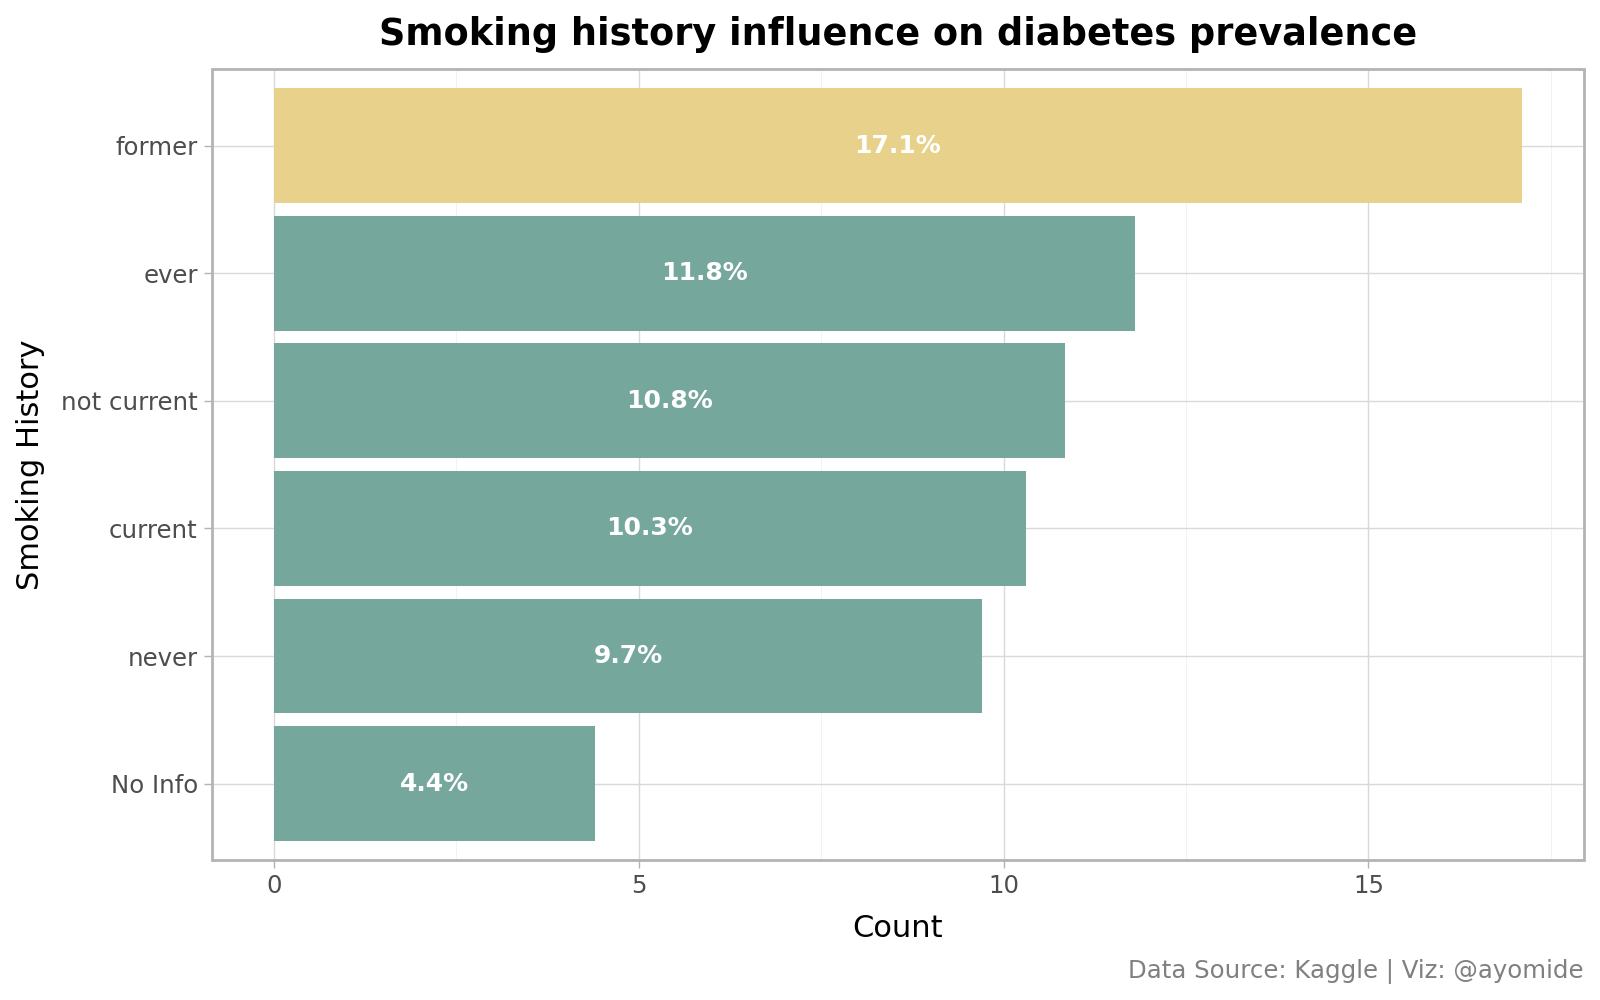

In [71]:
#Visualising...
(ggplot(smoking_diab, aes('reorder(smoking_history, perc)', 'perc')) + geom_col(fill = "#76a79d") + geom_col(highest, aes('reorder(smoking_history, perc)', 'perc'), fill = '#e8d28b')
 + geom_text(aes(label = 'perc'), format_string = '{:.1%}', position = position_stack(vjust=0.5), size = 9, fontweight = 'bold', color = 'white')
 + coord_flip()
 + scale_y_continuous(labels=lambda l: [f'{x * 100:.0f}' for x in l])
 + labs(x = 'Smoking History', 
       y = 'Count',
       title= 'Smoking history influence on diabetes prevalence',
       caption= 'Data Source: Kaggle | Viz: @ayomide')
+ theme_light()
+ theme(plot_caption=element_text(color='grey'), plot_title=element_text(fontweight = 'bold'), figure_size=(8, 5)))

**Plot Interpretation:** Former smokers have the highest case of diabetes with 17.1% followed by people that have smoked once in their lives. We can say that smoking has an association with diabetes, not directly but from our data, most diabetes patients have either smoked once in their lives, are current smokers or were former smokers.

8)  How does BMI differ between diabetic and non-diabetic patients?

In [72]:
#Selecting the two columns of Interest
bmi_dia = diabetes_clean[['bmi', 'diabetes']]

#Checking for the mean bmi for Diabetic & non-diabetic patients
bmi_dia = bmi_dia.groupby('diabetes')['bmi'].mean().reset_index()

#Mapping the diabetes column to convert from numbers to words. 0 - Not Diabetic; 1 - Diabetic
bmi_dia['diabetes'] = bmi_dia['diabetes'].map({0: 'Not Diabetic', 1: 'Diabetic'})
bmi_dia

,diabetes,bmi
0,Not Diabetic,26.869003
1,Diabetic,31.997755


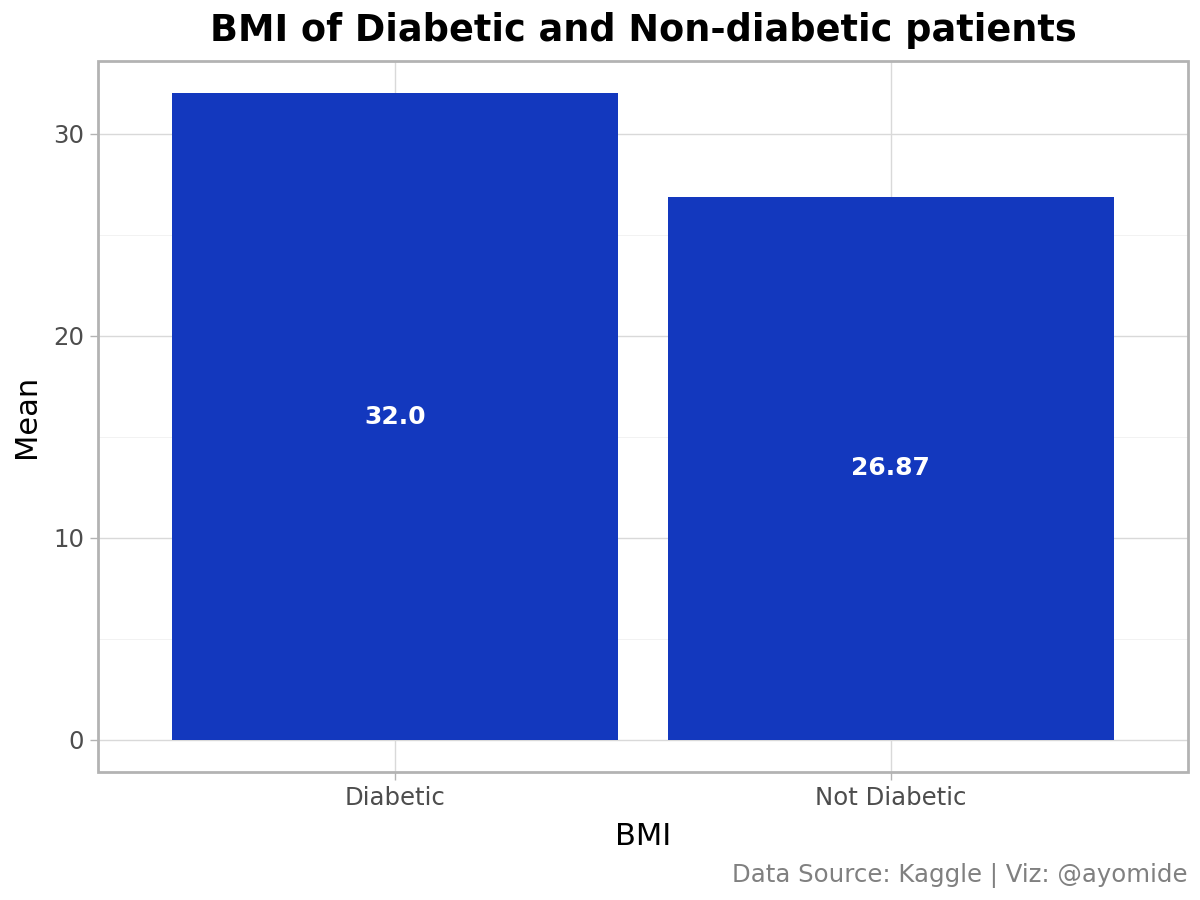

In [73]:
#Visualising...
(ggplot(bmi_dia, aes('diabetes', 'bmi')) + geom_col(fill = '#1338be') 
 + geom_text(aes(label = 'bmi'), format_string = '{:.4}', position = position_stack(vjust=0.5), color = 'white', size = 9, fontweight = 'bold')
 + labs(x = 'BMI', 
       y = 'Mean',
       title= 'BMI of Diabetic and Non-diabetic patients',
       caption= 'Data Source: Kaggle | Viz: @ayomide')
+ theme_light()
+ theme(plot_caption=element_text(color='grey'), plot_title=element_text(fontweight = 'bold'), figure_size=(6, 4.5)))

**Plot Interpretation:** From the plot, Diabetic patients have higher median/mean body mass index than Non-diabetic patients. The bmi of diabetic patients is 32 which indicates that most of our diabetic patients are obese. This might be due to the medications too.

9) How does HbA1c differ between diabetic and non-diabetic patients?

In [74]:
#Selecting the two columns of Interest
hb_dia = diabetes_clean[['HbA1c_level', 'diabetes']]

#Mapping the diabetes column to convert from numbers to words. 0 - Not Diabetic; 1 - Diabetic
hb_dia['diabetes'] = hb_dia['diabetes'].map({0: 'Not Diabetic', 1: 'Diabetic'})

hb_dia.head()

C:\Users\HomePC\AppData\Local\Temp\ipykernel_14156\2654872434.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


,HbA1c_level,diabetes
0,6.6,Not Diabetic
1,6.6,Not Diabetic
2,5.7,Not Diabetic
3,5.0,Not Diabetic
4,4.8,Not Diabetic


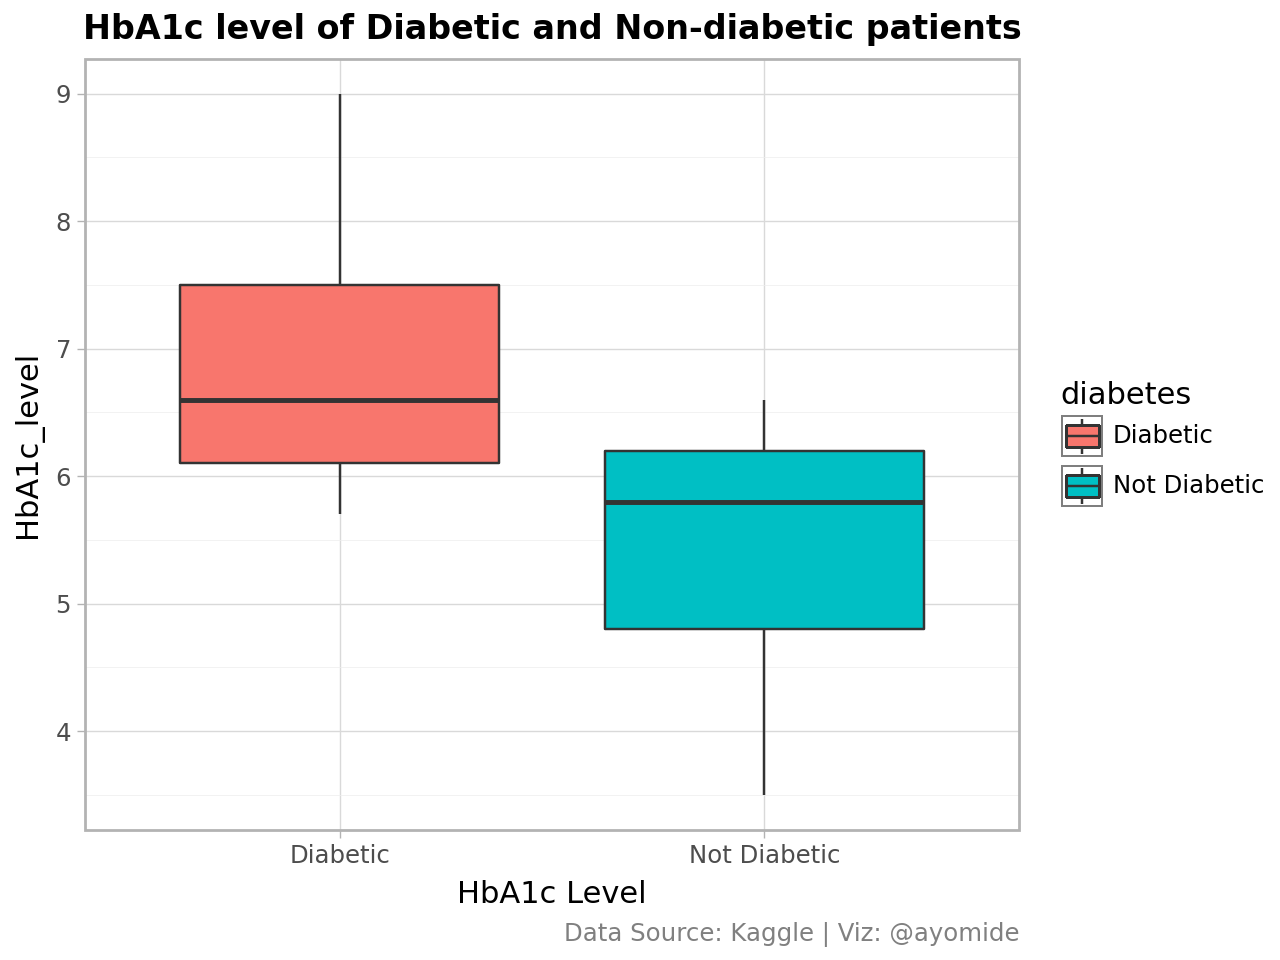

In [75]:
#Visualising...
(ggplot(hb_dia, aes('diabetes', 'HbA1c_level', fill = 'diabetes')) + geom_boxplot() 
 + labs(x = 'HbA1c Level', 
       title= 'HbA1c level of Diabetic and Non-diabetic patients',
       caption= 'Data Source: Kaggle | Viz: @ayomide')
      + theme_light()
+ theme(plot_caption=element_text(color='grey'), plot_title=element_text(fontweight = 'bold', size = 12)))

**Plot Interpretation:** From the plot, Diabetic patients have higher median/mean HbA1c level than Non-diabetic patients. The median HbA1c level of diabetic patients is about 6.6 while the median HbA1c level of a non-diabetic patients is about 5.7. This is an indicator that having an HbA1c level of >6.1 then you are either diabetic or have prediabetes. The normal HbA1c level ranges from 4.8 to 5.7.

10) Does blood glucose levels differ between diabetic and non-diabetic patients?

In [76]:
#Selecting the two columns of Interest
blood_glu = diabetes_clean[['blood_glucose_level', 'diabetes']]

#Mapping the diabetes columns to convert from numbers to words. 0 - Not Diabetic; 1 - Diabetic
blood_glu['diabetes'] = blood_glu['diabetes'].map({0: 'Not Diabetic', 1: 'Diabetic'})
blood_glu

C:\Users\HomePC\AppData\Local\Temp\ipykernel_14156\4053828763.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


,blood_glucose_level,diabetes
0,140,Not Diabetic
1,80,Not Diabetic
2,158,Not Diabetic
3,155,Not Diabetic
4,155,Not Diabetic
...,...,...
99994,145,Not Diabetic
99996,100,Not Diabetic
99997,155,Not Diabetic
99998,100,Not Diabetic


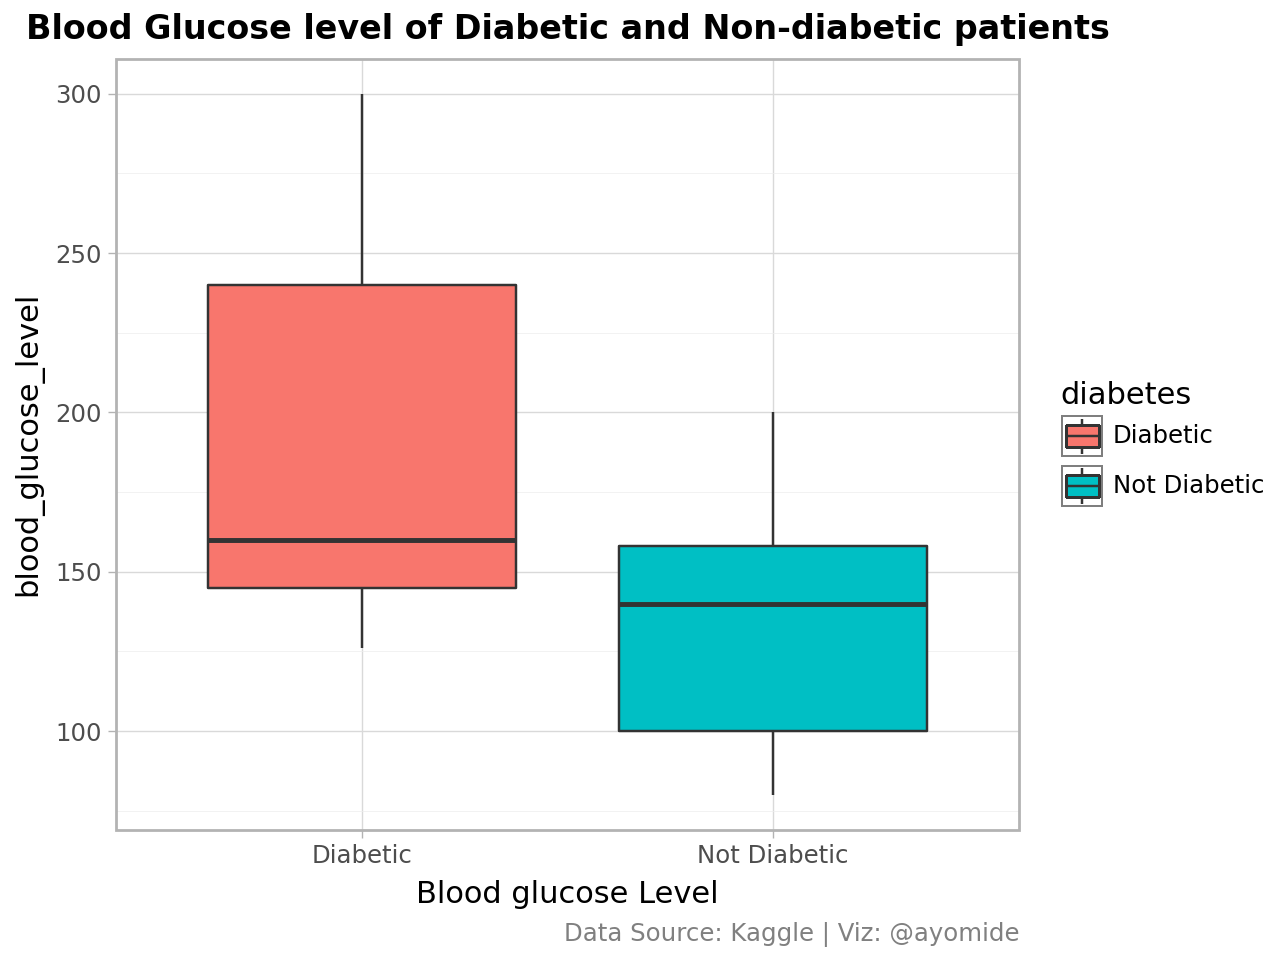

In [77]:
#Visualising...
(ggplot(blood_glu, aes('diabetes', 'blood_glucose_level', fill = 'diabetes')) + geom_boxplot() 
 + labs(x = 'Blood glucose Level', 
       title= 'Blood Glucose level of Diabetic and Non-diabetic patients',
       caption= 'Data Source: Kaggle | Viz: @ayomide')
      + theme_light()
+ theme(plot_caption=element_text(color='grey'), plot_title=element_text(fontweight = 'bold', size = 12)))

**Plot Interpretation:** From the plot, Diabetic patients have higher median/mean Blood glucose level than Non-diabetic patients. The mean blood glucose level of diabetic patients is about 194 while the mean blood glucose level of a non-diabetic patients is about 132.8. This is an indicator that having a blood_glucose level of >140, you are either diabetic or have prediabetes. The normal blood glucose level ranges from <100 to 110.

11) Which combinations of risk factors characterize diabetic patients?

In [78]:
import plotly.express as px

fig = px.scatter_3d(diabetes_clean, x= 'bmi', y = 'blood_glucose_level', z = 'HbA1c_level', color = 'diabetes')

fig.show()

**Interpretation:** A 3D scatter plot was created to determine the properties of diabetic patients. From the plot, the combination of risk factors are:  
1) `High BMI + High HbA1c level (>5.7) + High Blood glucose level(>130) = DIABETES`   
2) `Low BMI + High HbA1c level (>5.7) + High Blood glucose level(>130) = DIABETES`  
3) `Moderate BMI + High HbA1c level (>5.7) + High Blood glucose level(>130) = DIABETES`

12) Which factors show the strongest relationship with diabetes?

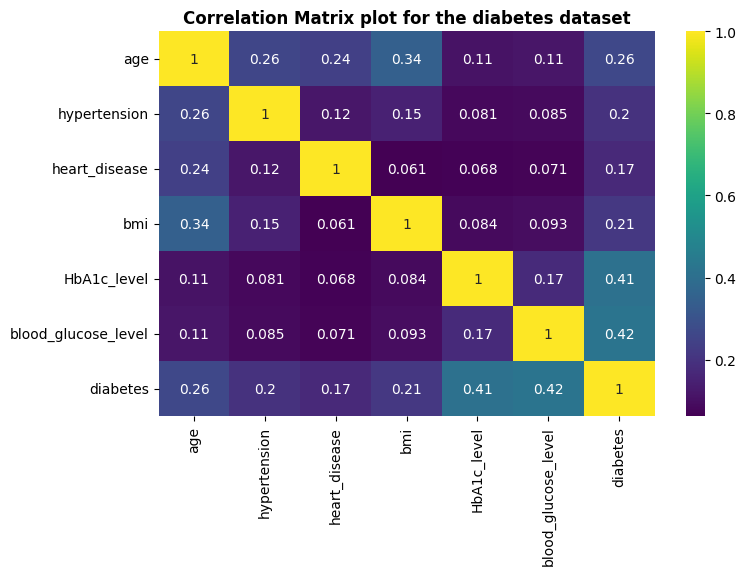

In [79]:
#Selecting the numeric columns
diab_corr = diabetes_clean.select_dtypes(include = [int, float])
diab_real_corr = diab_corr.corr()

#Visualising...
import seaborn as sns 
import matplotlib.pyplot as plt 

plt.figure(figsize=(8, 5))
sns.heatmap(diab_real_corr, cmap='viridis', annot=True)
plt.title('Correlation Matrix plot for the diabetes dataset', fontweight = 'bold')
plt.show()

**Plot Interpretation:** HbA1c level and blood glucose level are the most correlated to diabetes diagnosis (0.41 & 0.42). This means they're the most predictive features.
No multicollinearity concern.

##### Data Preprocessing

In [80]:
#Importing the necessary packages
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#The predictor and target variables
X = diabetes_clean.drop('diabetes', axis=1)
y = diabetes_clean['diabetes']

#Encoding the variables
X = pd.get_dummies(X, columns=['gender', 'smoking_history'], drop_first=True)

#Splitting the dataset into training & testing 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#Scaling the X_train and X_test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##### Logistic Regression

In [81]:
#Importing necessary packages & Initiating the Logistic Regression model
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight='balanced')
lr.fit(X_train_scaled, y_train)

#Checking for the coefficients (log odds)
log_odds = lr.coef_
#Changing it to the odds
odds = np.exp(log_odds)

#Checking for the Intercepts
intercept = lr.intercept_

#Turning to a dataframe for neater work
odds_df = pd.DataFrame(odds.T, X.columns, columns = ['Coefficient'])

odds_df.sort_values(by = 'Coefficient', ascending=False)

,Coefficient
HbA1c_level,10.033363
blood_glucose_level,3.637046
age,3.151525
bmi,1.885379
smoking_history_never,1.278029
hypertension,1.231485
smoking_history_current,1.189747
smoking_history_former,1.173225
gender_Male,1.170027
heart_disease,1.165760


Interpretation   
- 1 unit increase in HbA1c_level increases the odds of being diabetic by x10.  
- 1 unit increase in blood_glucose_level increases the odds of being diabetic by x3.  
- 1 unit increase in age increases the odds of being diabetic by x3.  
- 1 unit increase in bmi increases the odds of being diabetic by x89%.  

These are the strongest predictors of being Diabetes. This means that the higher these features in a human, the more likely the human is diabetic.


In [82]:
#predicting on the training data
predicted = lr.predict(X_train_scaled)

#Evaluating the model
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay, roc_curve, accuracy_score, recall_score, precision_score, f1_score
print(classification_report(predicted, y_train))

#Turning it to a DATAFRAME
comparison_df = pd.DataFrame({'Model': 'Logistic Regression', 
                              'Accuracy Score': [accuracy_score(predicted, y_train)], 
                              'Precision Score': [precision_score(predicted, y_train)], 
                              'Recall Score': [recall_score(predicted, y_train)],
                              'F1 Score': [f1_score(predicted, y_train)]})

comparison_df

              precision    recall  f1-score   support

           0       0.89      0.99      0.93     63038
           1       0.88      0.43      0.58     13878

    accuracy                           0.89     76916
   macro avg       0.89      0.71      0.76     76916
weighted avg       0.89      0.89      0.87     76916



,Model,Accuracy Score,Precision Score,Recall Score,F1 Score
0,Logistic Regression,0.88715,0.882994,0.431763,0.579946


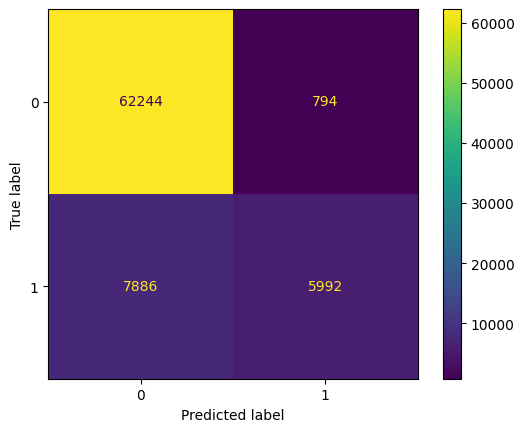

In [83]:
#Displaying the confusion matrix
ConfusionMatrixDisplay.from_predictions(predicted, y_train)
plt.show()

In [84]:
#Determining the ROC-AUC score
lr_y_score = lr.predict_proba(X_train_scaled)[:, 1]
print(roc_auc_score(y_train, lr_y_score))

#Adding the ROC-AUC Score to the comparison dataframe
comparison_df['ROC-AUC Score'] = [roc_auc_score(y_train, lr_y_score)]
comparison_df

0.9624296310220727


,Model,Accuracy Score,Precision Score,Recall Score,F1 Score,ROC-AUC Score
0,Logistic Regression,0.88715,0.882994,0.431763,0.579946,0.96243


##### Random Forest Classifier

In [85]:
#Importing necessary packages & Initiating the Random Forest model
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold

rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')

#Performing Cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_validate(rf_model, X_train_scaled, y_train, cv=cv, scoring= ["accuracy", "precision", "recall", "f1", 'precision_weighted', 'f1_weighted'])

cv_scores = pd.DataFrame({'Model': 'CV Random Forest', 
                              'Accuracy Score': [scores['test_accuracy'].mean()], 
                              'Precision Score': [scores['test_precision'].mean()], 
                              'Recall Score': [scores['test_recall'].mean()]})

cv_scores

,Model,Accuracy Score,Precision Score,Recall Score
0,CV Random Forest,0.968277,0.940283,0.683911


In [86]:
rf_model.fit(X_train_scaled, y_train)

#Predicting on the training data using the Random Forest model
predicted_rf = rf_model.predict(X_train_scaled)

#Evaluating the model
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
print(classification_report(predicted_rf, y_train))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     70068
           1       1.00      0.99      0.99      6848

    accuracy                           1.00     76916
   macro avg       1.00      1.00      1.00     76916
weighted avg       1.00      1.00      1.00     76916



In [87]:
#Determining the ROC-AUC score
rf_y_score = rf_model.predict_proba(X_train_scaled)[:, 1]
print(roc_auc_score(y_train, rf_y_score))

rf_df = pd.DataFrame({'Model' : 'Random Forest (no tuning parameters)',
'Accuracy Score' : [accuracy_score(predicted_rf, y_train)],
'Precision Score' : [precision_score(predicted_rf, y_train)],
'Recall Score' : [recall_score(predicted_rf, y_train)],
'F1 Score': [f1_score(predicted_rf, y_train)],
'ROC-AUC Score' : [roc_auc_score(y_train, rf_y_score)]})
rf_df

0.9999592027504476


,Model,Accuracy Score,Precision Score,Recall Score,F1 Score,ROC-AUC Score
0,Random Forest (no tuning parameters),0.99909,0.999411,0.990362,0.994866,0.999959


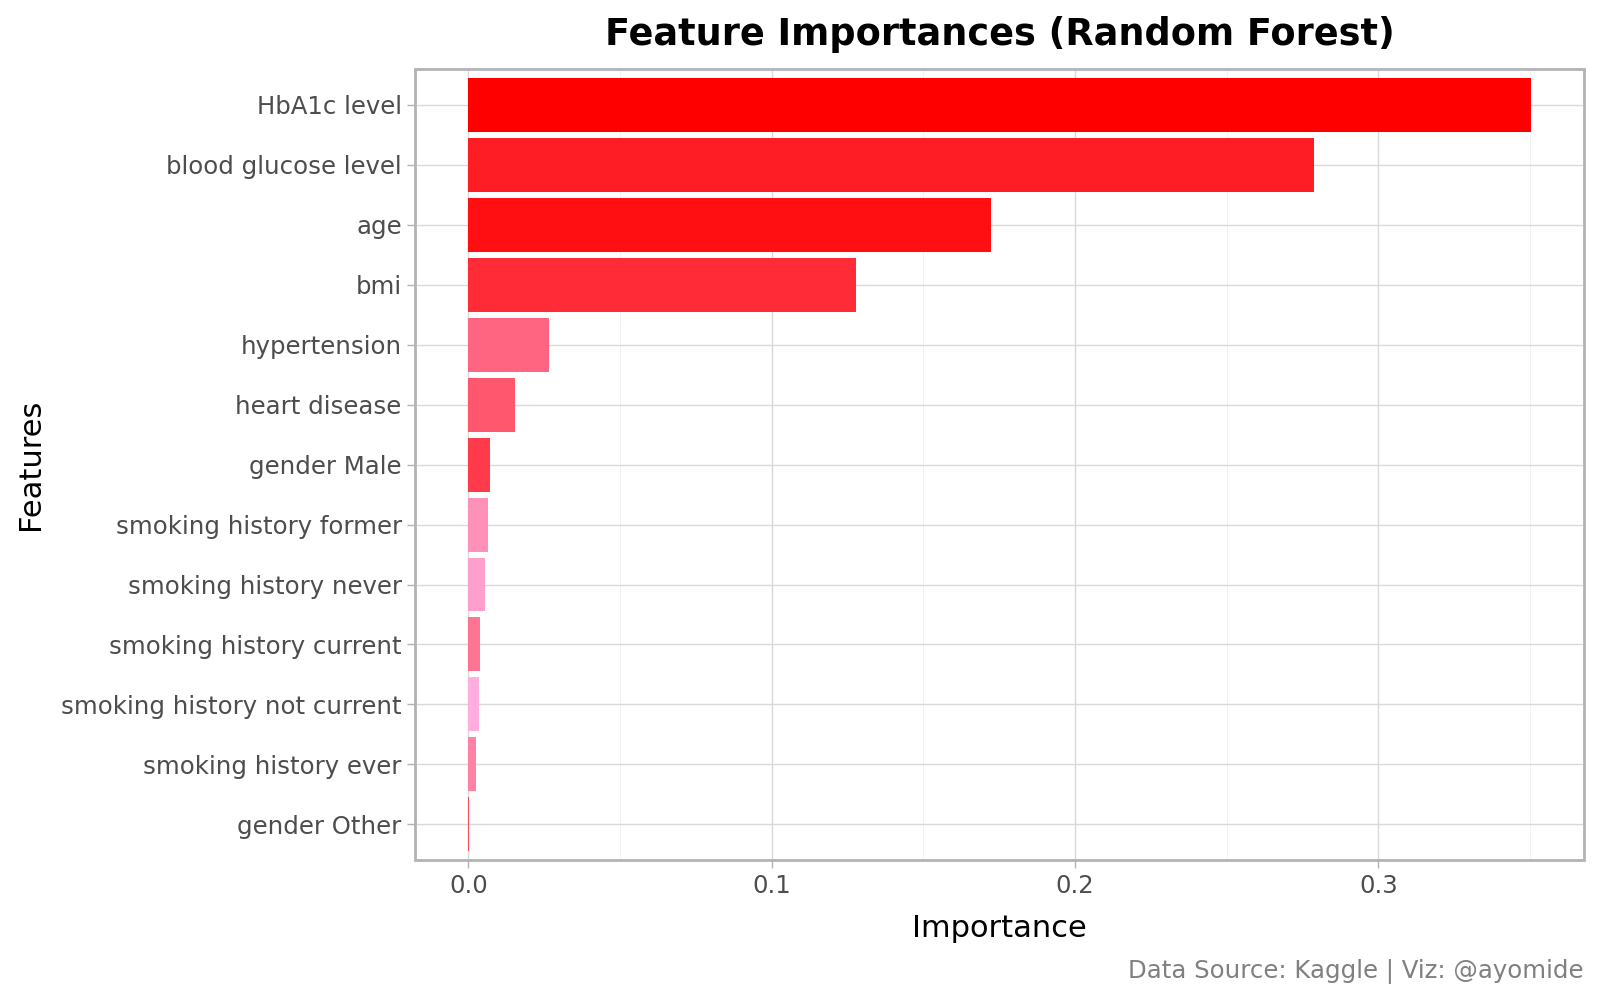

In [88]:
#features importance

features_importance = pd.DataFrame({'Features': X_train.columns.str.replace('_', ' '),
    'Importance': rf_model.feature_importances_})

(ggplot(features_importance, aes('reorder(Features, Importance)', 'Importance', fill = 'Features')) + geom_col()
 + coord_flip()
 + scale_fill_manual(values = ("#FF0000", "#FF0E12", "#FF1D25", "#FF2B37", "#FF3A4A", "#FF485C", "#FF576E",
"#FF6581", "#FF7493", "#FF82A6", "#FF91B8", "#FF9FCB", "#FFAEDD", "#FFBCF0"))
+ labs(x = 'Features', 
       y = 'Importance',
       title= 'Feature Importances (Random Forest)',
       caption= 'Data Source: Kaggle | Viz: @ayomide')
+ theme_light()
+ theme(plot_caption=element_text(color='grey'), plot_title=element_text(fontweight = 'bold'), figure_size=(8, 5))
+ theme(legend_position = 'none'))

**Plot Interpretation:** The most important features used in this model were HbA1c level, blood glucose level, age and bmi. They are the most important predictors.

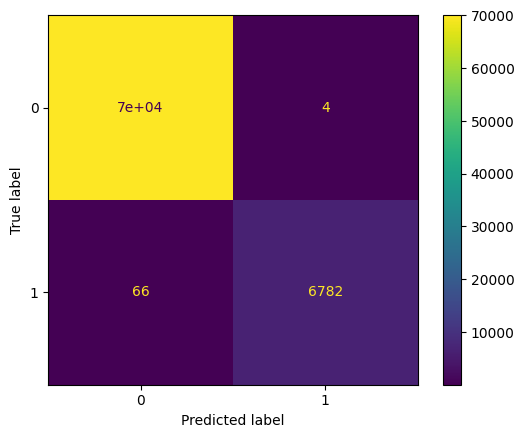

In [89]:
#Displaying the confusion matrix
ConfusionMatrixDisplay.from_predictions(predicted_rf, y_train)
plt.show()

##### Random Forest Classifier (Tuned)

In [90]:
#Using GridSearchCV to search for the best parameters
from sklearn.model_selection import GridSearchCV

#Identifying the parameter range
params = {'max_depth': list(range(1, 10)),
          'n_estimators': list(range(10, 200, 10))}

#Intiating the GridSearchCV
#grid_search = GridSearchCV(RandomForestClassifier(criterion='entropy', random_state=42, class_weight='balanced'), params, verbose = 2)

#grid_search.fit(X_train_scaled, y_train)

In [91]:
#RandomForestClassifier(class_weight='balanced', criterion='entropy',
                       #max_depth=1, n_estimators=30, random_state=42)

**Best Estimator**: Using Entropy as the criterion, the GridSearchCV gave a max_depth of 1 and n_estimators of 30 as the best estimators.

In [92]:
#Initiating the best Random Forest model determined from GridSearchCV
rf_model2 = RandomForestClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=1, n_estimators=30, random_state=42)

rf_model2.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",30
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [93]:
#Predicting on the training data using the Random Forest model (Tuned)
predicted_rf2 = rf_model2.predict(X_train_scaled)

#Evaluating
print(classification_report(predicted_rf2, y_train))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98     72420
           1       0.66      1.00      0.80      4496

    accuracy                           0.97     76916
   macro avg       0.83      0.98      0.89     76916
weighted avg       0.98      0.97      0.97     76916



In [94]:
#Determining the ROC-AUC score
rf2_y_score = rf_model2.predict_proba(X_train_scaled)[:, 1]
print(roc_auc_score(y_train, rf2_y_score))

#Putting in a df for neater work
rf_df2 = pd.DataFrame({'Model' : 'Random Forest (tuned)',
'Accuracy Score' : [accuracy_score(predicted_rf2, y_train)],
'Precision Score' : [precision_score(predicted_rf2, y_train)],
'Recall Score' : [recall_score(predicted_rf2, y_train)],
'F1 Score': [f1_score(predicted_rf2, y_train)],
'ROC-AUC Score' : [roc_auc_score(y_train, rf2_y_score)]})

0.9341839850365887


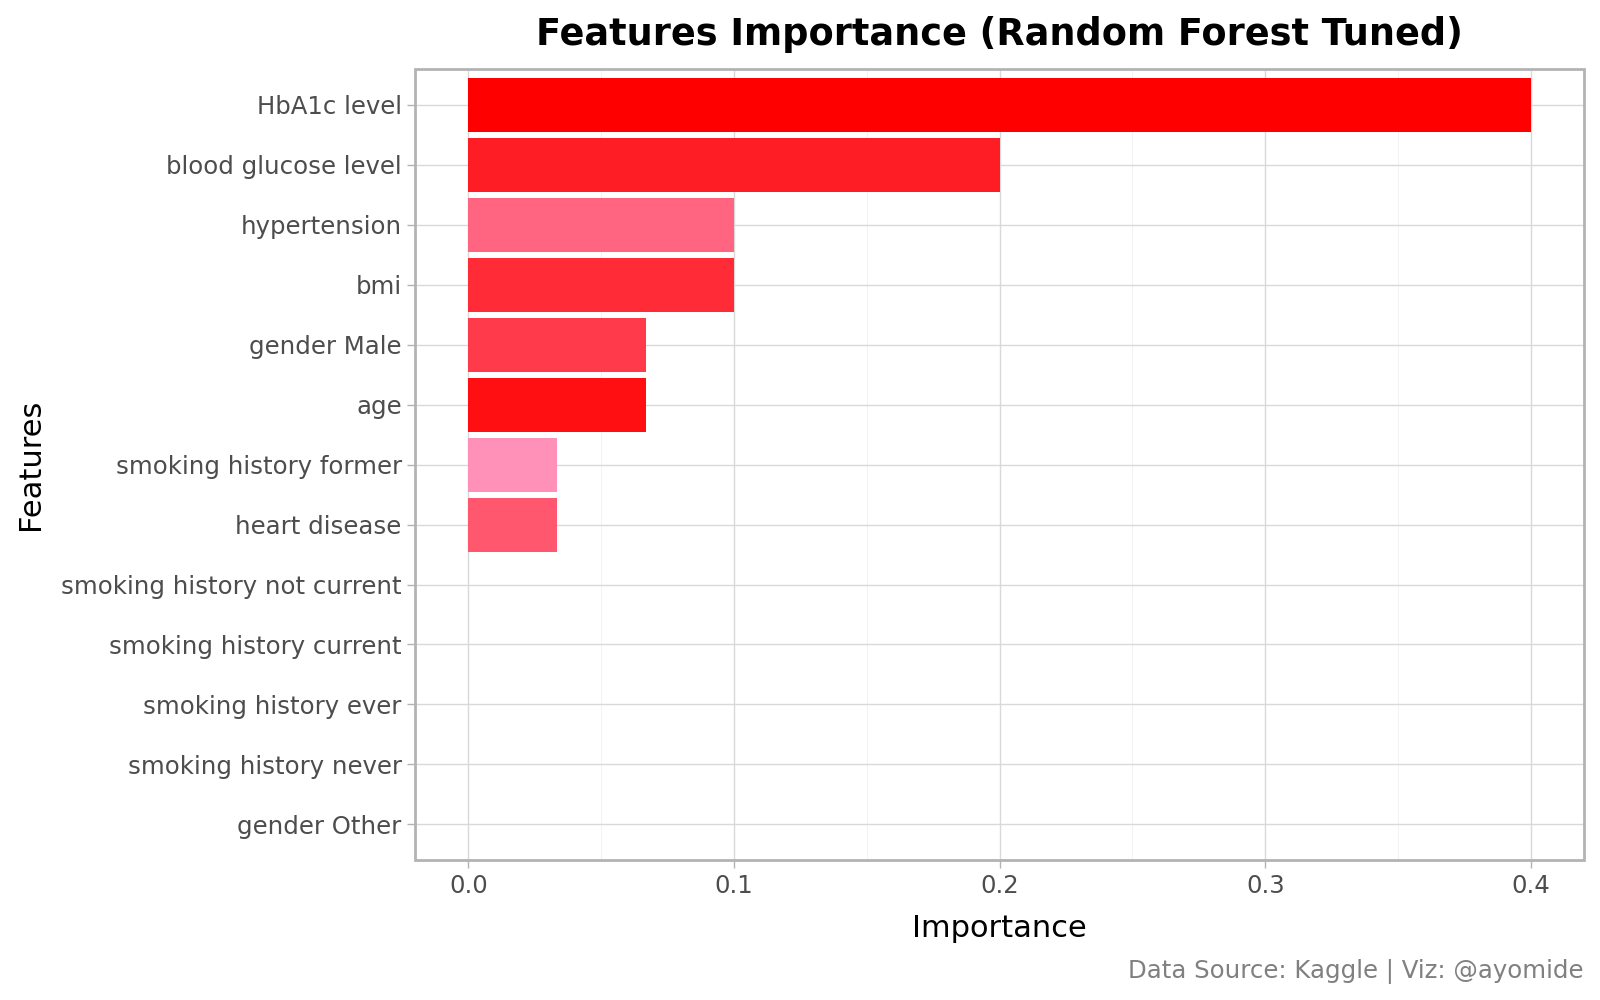

In [95]:
#features importance

features_importance2 = pd.DataFrame({'Features': X_train.columns.str.replace('_', ' '),
    'Importance': rf_model2.feature_importances_})

(ggplot(features_importance2, aes('reorder(Features, Importance)', 'Importance', fill = 'Features')) + geom_col()
 + coord_flip()
 + scale_fill_manual(values = ("#FF0000", "#FF0E12", "#FF1D25", "#FF2B37", "#FF3A4A", "#FF485C", "#FF576E",
"#FF6581", "#FF7493", "#FF82A6", "#FF91B8", "#FF9FCB", "#FFAEDD", "#FFBCF0"))
+ labs(x = 'Features', 
       y = 'Importance',
       title= 'Features Importance (Random Forest Tuned)',
       caption= 'Data Source: Kaggle | Viz: @ayomide')
+ theme_light()
+ theme(plot_caption=element_text(color='grey'), plot_title=element_text(fontweight = 'bold'), figure_size=(8, 5))
+ theme(legend_position = 'none'))

**Plot Interpretation:** The most important features used in this model were HbA1c level, blood glucose level, hypertension and bmi. They are the most important predictors.

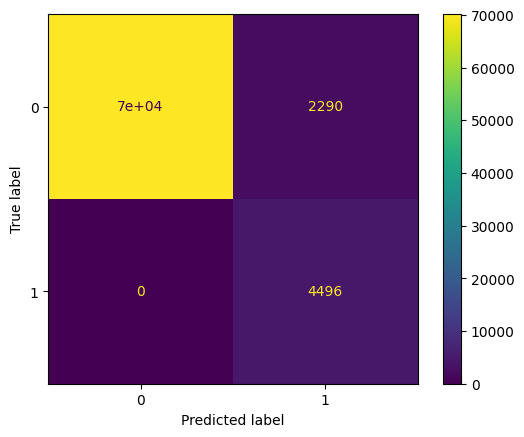

In [96]:
#Displaying the confusion matrix
ConfusionMatrixDisplay.from_predictions(predicted_rf2, y_train)
plt.show()

##### Comparing the Model Scores

In [97]:
#Merging the three dataframes
comparison_df = pd.concat([comparison_df, rf_df, rf_df2], ignore_index=True)

#Approximating the numerical values to 2 decimal place
comparison_df = comparison_df.round(2)


In [98]:
comparison_df

,Model,Accuracy Score,Precision Score,Recall Score,F1 Score,ROC-AUC Score
0,Logistic Regression,0.89,0.88,0.43,0.58,0.96
1,Random Forest (no tuning parameters),1.00,1.00,0.99,0.99,1.00
2,Random Forest (tuned),0.97,0.66,1.00,0.80,0.93


The best model overall is the Random Forest (Tuned). It has the better metrics score and does not overfit, So we would use it to predict on the test data.

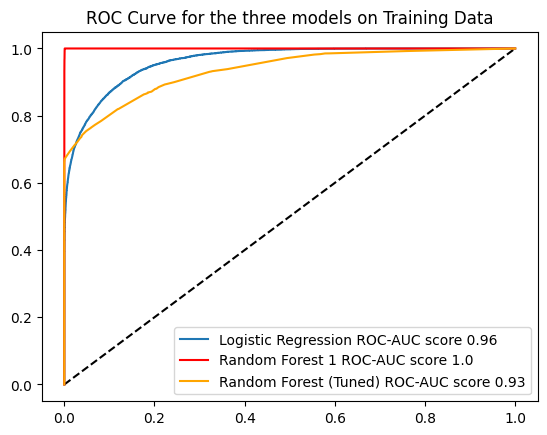

In [99]:
#Getting the False positive ratio, True positive and Thresholds from thr roc-auc
fpr_lr, tpr_lr, thresholds = roc_curve(y_train, lr_y_score)
fpr_rf1, tpr_rf1, thresholds1 = roc_curve(y_train, rf_y_score)
fpr_rf2, tpr_rf2, thresholds2 = roc_curve(y_train, rf2_y_score)


import matplotlib.pyplot as plt

plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr_lr, tpr_lr, label = 'Logistic Regression ROC-AUC score 0.96')
plt.plot(fpr_rf1, tpr_rf1, color = 'red', label = 'Random Forest 1 ROC-AUC score 1.0')
plt.plot(fpr_rf2, tpr_rf2, color = 'orange', label = 'Random Forest (Tuned) ROC-AUC score 0.93')
plt.title('ROC Curve for the three models on Training Data')
plt.legend()
plt.show()

**Interpretation:**   
- The *Blue* Curve is for the Logistic Regression model which is 0.96, it is an excellent model.  
- The *Red* Curve is for the first Random Forest model which is 1. It is very obvious the model overfits.  
- The *Orange* ROC Curve is for the second Random Forest model which is 0.93.


##### Predicting on the Test Data with the best model & Evaluation

In [100]:
#Predicting on test data
predicted_diab = rf_model2.predict(X_test_scaled)

#ROC-AUC Score
predicted_roc = rf_model2.predict_proba(X_test_scaled)[:, 1]

#Putting in a df for neater work
predicted_diab_df = pd.DataFrame({'Model' : 'Random Forest (tuned)',
'Accuracy Score' : [accuracy_score(predicted_diab, y_test)],
'Precision Score' : [precision_score(predicted_diab, y_test)],
'Recall Score' : [recall_score(predicted_diab, y_test)],
'F1 Score': [f1_score(predicted_diab, y_test)],
'ROC-AUC Score' : [roc_auc_score(y_test, predicted_roc)]})

#Approximating the numerical values to 2 decimal place
predicted_diab_df = predicted_diab_df.round(2)

print(classification_report(predicted_diab, y_test))
predicted_diab_df

              precision    recall  f1-score   support

           0       1.00      0.97      0.98     18086
           1       0.67      1.00      0.81      1144

    accuracy                           0.97     19230
   macro avg       0.84      0.98      0.90     19230
weighted avg       0.98      0.97      0.97     19230



,Model,Accuracy Score,Precision Score,Recall Score,F1 Score,ROC-AUC Score
0,Random Forest (tuned),0.97,0.67,1.0,0.81,0.93


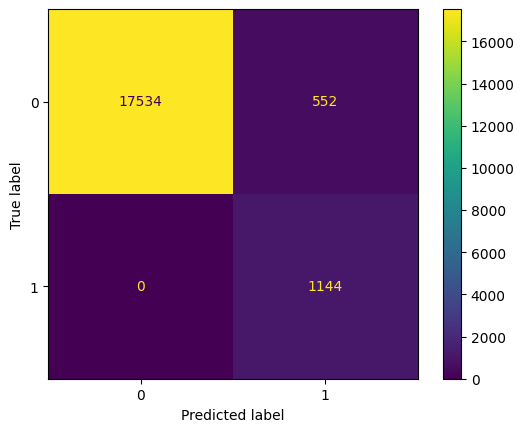

In [101]:
#Displaying the confusion matrix
ConfusionMatrixDisplay.from_predictions(predicted_diab, y_test)
plt.show()

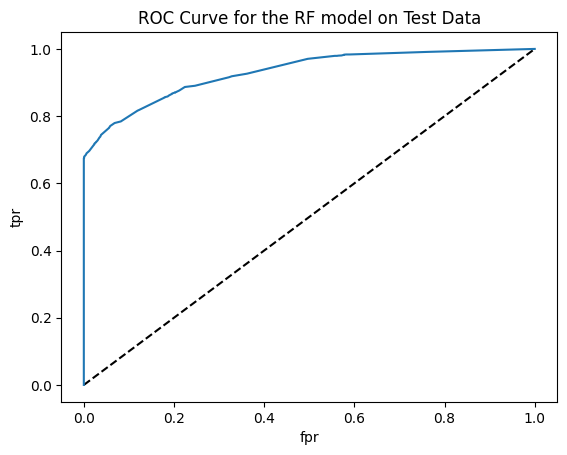

In [102]:
#Getting the False positive ratio, True positive and Thresholds from thr roc-auc
fpr, tpr, thresholds_pred = roc_curve(y_test, predicted_roc)


import matplotlib.pyplot as plt

plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr)
plt.title('ROC Curve for the RF model on Test Data')
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.show()

 **Testing the linear regression model on the test data:** The classification report showed that the model did an excellent job predicting diabetes diagnosis.
- 17534 records were correctly predicted as Non-Diabetes patients.  
- 1144 records were correctly predicted as Diabetes patients. All actual diabetes patients records were correctly predicted.
- 552 records were incorrectly predicted as Diabetes patients.  

The model did an excellent job predicting.

## Summary

This project focused on developing a machine learning model to predict the probability that a patient will be diagnosed with diabetes based on medical and demographic data. The analysis was conducted using a dataset containing 100,000 patient records which is highly imbalanced, 8.8% of patients diagnosed with diabetes and 91.2% as non-diabetic. During data interrogation, 3,854 duplicate records were identified and dropped, while no missing values were detected. The dataset comprised a mix of numerical features with both integer and floating-point data types.   
Exploratory data analysis (EDA) helped uncover key patterns and insights related to diabetes outcomes. The dataset was split using a using an 80:20 ratio into training and testing sets. Three machine learning algorithms were trained and evaluated on the training dataset. The best-performing model was applied to the test dataset for final evaluation. The model demonstrated strong predictive performance, achieving an accuracy score of 97%, precision of 67%, recall of 100%, F1-score of 81%, and a ROC-AUC score of 93%.

### Key Patterns & Insights    
- HbA1c level (Hemoglobin A1c) and Blood Glucose level are the strongest predictors of diabetes, showing the highest correlation values (0.42 and 0.41 respectively). Higher values of both indicators are strongly associated with increased likelihood of diabetes.  

- Patients with diabetes have a significantly higher BMI compared to non-diabetic patients (mean BMI: 32 vs 26), indicating that obesity is a key risk factor.  

- Age is weakly correlated with diabetes, but prevalence is higher among older individuals, particularly those aged 45 years and above.

- Patients with a history of smoking show a higher prevalence of diabetes, suggesting an association between smoking status and diabetes occurrence.

- Heart disease and hypertension are not statistically associated with diabetes prediction, as confirmed using the Chi-square test of independence.

Overall, diabetes risk is most strongly influenced by HbA1c levels, blood glucose levels, and BMI irrespective of the gender, while other factors such as age, smoking, and comorbidities show weaker or mixed associations. 

### Machine Learning   

The data, after being split into an 80:20 ratio and categorical columns encoded was scaled and fit into 3 machine learning models on the training set. I used the accuracy, recall, precision, f1 score and roc-auc score to estimate how good the models were. 

- **Logistic Regression:** This model revealed the features that increases the odds of the patient being diabetic. As expected, HbA1c level, blood glucose level, bmi and age topped the list. The model achieved an accuracy of 89%, precision of 88%, recall of 43%, and a ROC-AUC score of 96%. While the model demonstrated strong overall discrimination ability and high precision, its recall was relatively low, indicating that it failed to identify a substantial number of diabetic patients. the model correctly classified 5,992 diabetic patients, but incorrectly classified 7,886 diabetic patients as non-diabetic (false negatives). In the healthcare setting, false negatives are particularly concerning because affected patients may go undetected and therefore miss timely diagnosis and treatment. This led us to explore other models.

- **Random forest (not tuned):** was developed using a balanced class weight setting to address class imbalance, with a random state of 42 to ensure reproducibility. Model performance was initially evaluated using 5-fold Stratified Cross-Validation, which produced an average accuracy of 97%, precision of 94%, and recall of 68%. After training the model on the full training dataset, it achieved an accuracy of 100%, precision of 99%, recall of 100%, and an F1-score of 99%. While these results indicate an excellent fit to the training data, they didn't perform well on the test data. As expected, the feature importance analysis revealed that HbA1c level, blood glucose level, age, and BMI were the most influential predictors, highlighting their significance in determining diabetes risk. The model correctly identified 6,782 diabetic patients and incorrectly classified only 66 diabetic patients as non-diabetic. This substantial reduction in false negatives compared to the Logistic Regression model demonstrates the Random Forest model's improved ability to detect diabetic patients, making it a more suitable candidate for medical screening and early diagnosis applications.

- **Random Forest (Tuned):** To further improve predictive performance, a second Random Forest model was developed and optimized using GridSearchCV. Hyperparameter tuning identified the optimal configuration as 30 estimators, entropy as the splitting criterion, and a maximum depth of 1 restriction. It produced a score of 97%, precision score of 66%, recall of 100%	and ROC-AUC score of 93%. This improvement demonstrates the value of hyperparameter tuning in enhancing model performance and predictive capability. The optimized model demonstrated exceptional classification performance on the training data, correctly identifying all diabetic patients and producing no false negatives. In other words, every diabetic patient in the training dataset was successfully detected by the model.  

#### Test Set Evaluation and Final Model Performance

The optimized Random Forest model was used to predict on the test dataset and evaluated. The model achieved an accuracy of 97%, precision of 67%, recall of 100%, F1-score of 81%, and a ROC-AUC score of 93%.

A key strength of the model was its ability to identify all diabetic patients correctly, resulting in zero false negatives and a perfect recall score of 100%. This is particularly important in a healthcare setting, where failing to detect a patient with diabetes could delay treatment and increase the risk of complications. The model's precision of 67% indicates that some patients predicted as diabetic were not actually diabetic, resulting in false positives. While this may lead to additional screening or follow-up testing, false positives are generally considered less harmful than false negatives.   

Overall, the model demonstrated strong predictive performance and proved highly effective as a diabetes screening tool. The feature importance analysis consistently identified HbA1c level, blood glucose level, BMI, and age as the most influential predictors of diabetes across all models evaluated.

### Challenges and Recommendations  

The primary challenge encountered was the significant class imbalance in the dataset. Only 8.8% of patients were diabetic, while 91.2% were non-diabetic. This imbalance increased the risk of developing models that favor the majority class and achieve high accuracy while failing to correctly identify diabetic patients.   


Recommendations    
- Future studies should aim to collect additional records of diabetic patients to reduce class imbalance and improve the model's ability to learn minority-class patterns.

- The model should be tested on independent datasets from different hospitals, regions.  

- Healthcare providers can use the model to identify patients at high risk of diabetes and prioritize them for further clinical assessment and diagnostic testing.    

- Routine diabetes screening should be encouraged among middle-aged and older adults.   

- Government should put in place public health programs that should encourage, Healthy eating habits; Regular physical activity and Weight management interventions to reduce diabetes risk.  

- Healthcare organizations should consider integrating similar machine learning-based risk assessment tools into routine screening programs to support early detection, timely intervention, and improved management of diabetes.
